## Import Libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Reading Data

In [32]:
df = pd.read_csv('bank.csv')

## EXPLORATORY DATA ANALYSIS (EDA)

In [33]:
print("FIRST 5 ROWS:")
print(df.head())
print("\n" + "="*60)

FIRST 5 ROWS:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  



### DATASET SHAPE:

In [34]:
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

11162 rows, 17 columns


### COLUMN NAMES:

In [35]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


### DATA TYPES:

In [36]:
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


### MISSING VALUES PER COLUMN

In [37]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


### STATISTICAL SUMMARY (Numerical columns)

In [38]:
print(df.describe())

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


### TARGET COLUMN 'deposit' DISTRIBUTION:

In [39]:
print(df['deposit'].value_counts())
print("\nPercentage:")
print(df['deposit'].value_counts(normalize=True) * 100)

deposit
no     5873
yes    5289
Name: count, dtype: int64

Percentage:
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


### UNIQUE VALUES IN CATEGORICAL COLUMNS:

In [40]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Values: {df[col].unique()}")



job:
  Unique values: 12
  Values: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

marital:
  Unique values: 3
  Values: ['married' 'single' 'divorced']

education:
  Unique values: 4
  Values: ['secondary' 'tertiary' 'primary' 'unknown']

default:
  Unique values: 2
  Values: ['no' 'yes']

housing:
  Unique values: 2
  Values: ['yes' 'no']

loan:
  Unique values: 2
  Values: ['no' 'yes']

contact:
  Unique values: 3
  Values: ['unknown' 'cellular' 'telephone']

month:
  Unique values: 12
  Values: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
  Unique values: 4
  Values: ['unknown' 'other' 'failure' 'success']


### CHECK FOR NEGATIVE OR WEIRD VALUES:


In [41]:
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
for col in numerical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Min: {df[col].min()}")
        print(f"  Max: {df[col].max()}")
        print(f"  Negative values: {(df[col] < 0).sum()}")
print("="*60)


age:
  Min: 18
  Max: 95
  Negative values: 0

balance:
  Min: -6847
  Max: 81204
  Negative values: 688

day:
  Min: 1
  Max: 31
  Negative values: 0

duration:
  Min: 2
  Max: 3881
  Negative values: 0

campaign:
  Min: 1
  Max: 63
  Negative values: 0

pdays:
  Min: -1
  Max: 854
  Negative values: 8324

previous:
  Min: 0
  Max: 58
  Negative values: 0


## Preprocessing data


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

# label encoding on non-ordinal data
le = LabelEncoder()
df['month'] = le.fit_transform(df['month'])
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
le = LabelEncoder()
df['deposit'] = le.fit_transform(df['deposit'])

# One shot encoding
df = pd.get_dummies(df, columns=['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome'])


In [43]:
df = df.drop('duration', axis=1)

In [44]:
print(df.shape)
print(df.columns.tolist())

(11162, 37)
['age', 'education', 'balance', 'day', 'month', 'campaign', 'pdays', 'previous', 'deposit', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


## Separation of features (X) and target (y)

In [45]:
X = df.drop('deposit', axis=1)
y = df['deposit']  # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8929, 36)
X_test shape: (2233, 36)
y_train shape: (8929,)
y_test shape: (2233,)


## Feature Scaling

In [46]:
scaler = StandardScaler()
num_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])


* # **Applying Algorithms**

### **KNN Algorithm**

In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\nKNN RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))




KNN RESULTS:
Accuracy: 0.6659
              precision    recall  f1-score   support

           0       0.66      0.75      0.70      1166
           1       0.68      0.58      0.62      1067

    accuracy                           0.67      2233
   macro avg       0.67      0.66      0.66      2233
weighted avg       0.67      0.67      0.66      2233



#### KNN Confusion Matrix & Heat Map

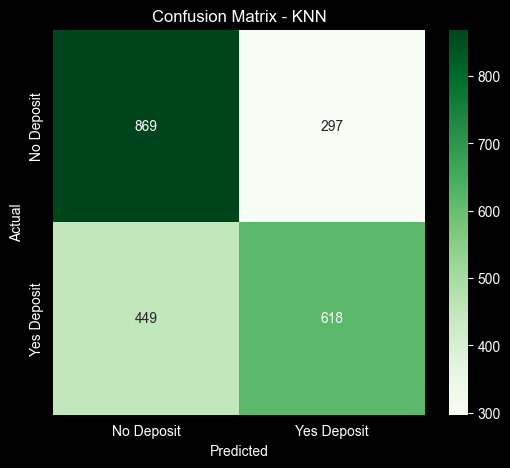

In [48]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Deposit', 'Yes Deposit'],
            yticklabels=['No Deposit', 'Yes Deposit'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show(block=True)

In [49]:
print("\nConfusion Matrix (KNN):")
print(f"True Negatives (correct NO):  {cm[0][0]}")
print(f"False Positives (wrong YES): {cm[0][1]}")
print(f"False Negatives (missed YES): {cm[1][0]}")
print(f"True Positives (correct YES): {cm[1][1]}")


Confusion Matrix (KNN):
True Negatives (correct NO):  869
False Positives (wrong YES): 297
False Negatives (missed YES): 449
True Positives (correct YES): 618


### **ANN Algorithm**

In [50]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)

ann.fit(X_train, y_train)
y_pred_ann = ann.predict(X_test)

print("ANN RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ann):.4f}")
print(classification_report(y_test, y_pred_ann))


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


#### ANN Confusion Matrix & Heat map

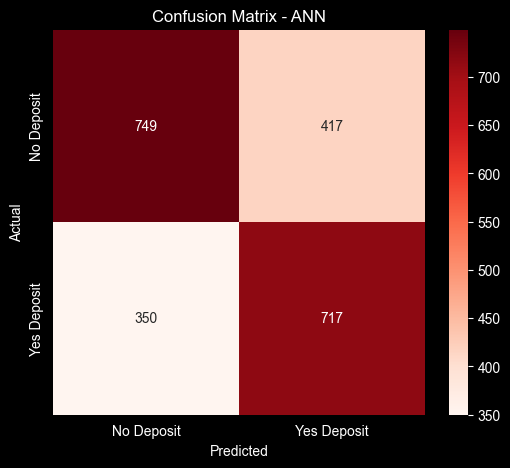

In [51]:
cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Deposit', 'Yes Deposit'],
            yticklabels=['No Deposit', 'Yes Deposit'])
plt.title('Confusion Matrix - ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show(block=True)


In [52]:
print("\nConfusion Matrix (ANN):")
print(f"True Negatives (correct NO):  {cm[0][0]}")
print(f"False Positives (wrong YES): {cm[0][1]}")
print(f"False Negatives (missed YES): {cm[1][0]}")
print(f"True Positives (correct YES): {cm[1][1]}")


Confusion Matrix (ANN):
True Negatives (correct NO):  749
False Positives (wrong YES): 417
False Negatives (missed YES): 350
True Positives (correct YES): 717


### Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DECISION TREE RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

DECISION TREE RESULTS:
Accuracy: 0.6646
              precision    recall  f1-score   support

           0       0.64      0.82      0.72      1166
           1       0.72      0.49      0.58      1067

    accuracy                           0.66      2233
   macro avg       0.68      0.66      0.65      2233
weighted avg       0.68      0.66      0.65      2233



#### Decision Tree Confusion Matrix & Heatmap

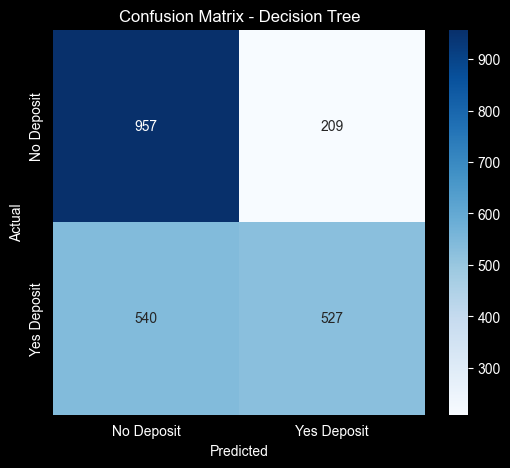

In [54]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Deposit', 'Yes Deposit'],
            yticklabels=['No Deposit', 'Yes Deposit'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show(block=True)

In [55]:
print("\nConfusion Matrix (Decision Tree):")
print(f"True Negatives (correct NO):  {cm[0][0]}")
print(f"False Positives (wrong YES): {cm[0][1]}")
print(f"False Negatives (missed YES): {cm[1][0]}")
print(f"True Positives (correct YES): {cm[1][1]}")


Confusion Matrix (Decision Tree):
True Negatives (correct NO):  957
False Positives (wrong YES): 209
False Negatives (missed YES): 540
True Positives (correct YES): 527


### Naive-Bayes

In [56]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("\nNAIVE BAYES RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(classification_report(y_test, y_pred_nb))


NAIVE BAYES RESULTS:
Accuracy: 0.6713
              precision    recall  f1-score   support

           0       0.67      0.72      0.70      1166
           1       0.67      0.61      0.64      1067

    accuracy                           0.67      2233
   macro avg       0.67      0.67      0.67      2233
weighted avg       0.67      0.67      0.67      2233



#### Naive-Bayes Confusion Matrix & Heatmap

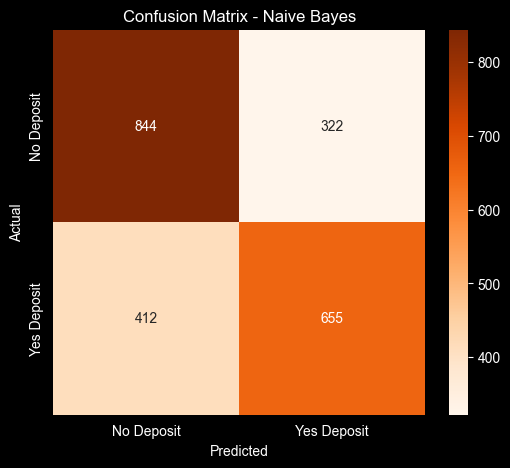

In [57]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Deposit', 'Yes Deposit'],
            yticklabels=['No Deposit', 'Yes Deposit'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show(block=True)

In [58]:
print("\nConfusion Matrix (Naive Bayes):")
print(f"True Negatives (correct NO):  {cm[0][0]}")
print(f"False Positives (wrong YES): {cm[0][1]}")
print(f"False Negatives (missed YES): {cm[1][0]}")
print(f"True Positives (correct YES): {cm[1][1]}")


Confusion Matrix (Naive Bayes):
True Negatives (correct NO):  844
False Positives (wrong YES): 322
False Negatives (missed YES): 412
True Positives (correct YES): 655
